Adelaide Rainfall Patterns 

In [ ]:
#importing libraries used
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import sqlalchemy



Loading data in Pandas Data Frames

In [335]:
#load CSV file (1 from West Terrace )
#data frame (table data structure)
df1 = pd.read_csv("IDCJAC0009_023000_1800_Data.csv") #Read west terrace data into df1
filtered_df1 = df1[(df1['Year'] < 1979) | (df1['Year'] > 2019)] #filter out dates 1979-2019 (missing data)

df2 = pd.read_csv("IDCJAC0009_023090_1800_Data.csv") #Read Kent Town data into df2
filtered_df2 = df2[(df2['Year'] >= 1979) & (df2['Year'] <= 2019)] #use only data in dates filtered out of df1

df_combined = pd.concat([filtered_df1, filtered_df2]) #data frame for west terrace data and kent combined

#df_combined[df_combined["Rainfall amount (millimetres)"] > 0]


Here we will group the dataframe by the total rainfall by year using the pandas .groupby method. 

In [336]:
# Grouping the combined dataframe by total rainfall using pandas .groupby method into series. (Like dictionary)
yearly_rainfall = df_combined.groupby('Year')['Rainfall amount (millimetres)'].sum() #All years rainfall
ten_year_rainfall = df_combined.groupby((df_combined['Year'] // 10) * 10)['Rainfall amount (millimetres)'].sum() #Rainfall for each 10yrs

#Removing incomplete years from dataset 
yearly_rainfall = yearly_rainfall.drop([2026])
ten_year_rainfall = ten_year_rainfall.drop([1830, 2020]) #.drop a pandas method. Python list requires .remove(value) or .remove[index]

#Table for 10 year rainfall count
ten_year_rainfall.to_frame() #.to_frame is a jupyter thing 



,Rainfall amount (millimetres)
Year,
1840,5433.4
1850,5724.0
1860,5045.6
1870,5556.5
1880,5177.8
1890,4961.5
1900,5610.9
1910,5109.4
1920,5689.4


Then matplotlib library will be used to create bar graphs of this data. 

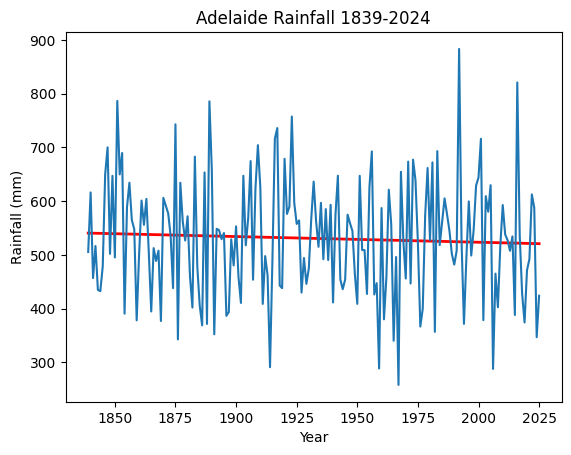

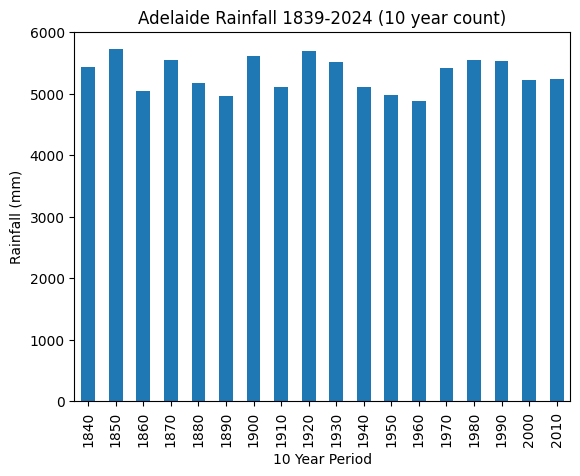

In [337]:

#All years rainfall bar graph

z = np.polyfit(yearly_rainfall.index, yearly_rainfall.values, 1)
p = np.poly1d(z)

plt.plot(yearly_rainfall.index, p(yearly_rainfall.index), color='red', linewidth=2, label='Trend')

yearly_rainfall.plot(kind='line')
plt.title('Adelaide Rainfall 1839-2024')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.show()

#Adjusted to 10 year averages. 
ten_year_rainfall.plot(kind='bar')
plt.title('Adelaide Rainfall 1839-2024 (10 year count)')
plt.xlabel('10 Year Period')
plt.ylabel('Rainfall (mm)')
plt.show()



Based on these graphs, it seems there is no significant up or down trends (very minor negative trend in graph 1) since measurments have been taken in Adelaide. However, this only measures total quantity of rain. Is there are observable change in rain consistency? 

Here, we calculate the yearly rainfall standard deviation. The SD measures how much data points typically deviate from the mean, meaning it pretty much measures variation. The SD for total yearly rainfall was 110.4, which suggests rainfall generally is not partiularly consistent year by year. Furthermore, the pre-1970/post-1970 SD shows that rainfall has become slightly more variable in recent years. 

In [338]:
#Total standard deviation of all rainfall.
print("Standard deviation for total yearly rainfall: ", yearly_rainfall.std())

#Standard deviation pre/post 1970 comparison
print("Pre 1970 stardard dev: ", yearly_rainfall[yearly_rainfall.index < 1970].std())
print("Post 1970 standard dev:", yearly_rainfall[yearly_rainfall.index >= 1970].std())


Standard deviation for total yearly rainfall:  110.39874746316293
Pre 1970 stardard dev:  107.7035462041256
Post 1970 standard dev: 117.38591123232871


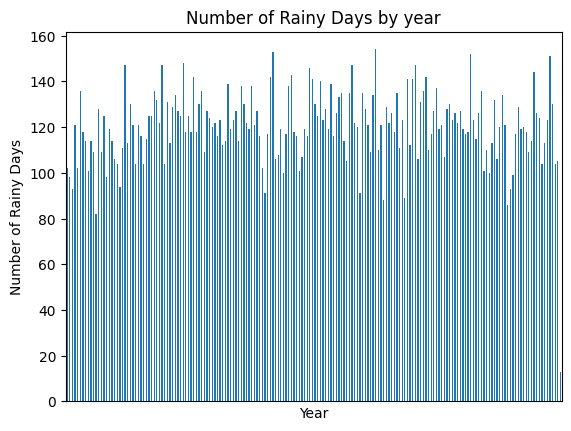

In [339]:
#Graph of number of rainy days
rainy_days = df_combined[df_combined['Rainfall amount (millimetres)'] > 0].groupby('Year').size()

#Adjusted to 10 year averages. 
rainy_days.plot(kind='bar')
plt.title('Number of Rainy Days by year')
plt.xlabel('Year')
plt.ylabel('Number of Rainy Days')
plt.xticks([]) #Remove labels for each x axis entry
plt.show()



Even if modern rainfall counts seem to be generally consistent with historical measurements, is the times at which it falls consistent? 

In [340]:
#Overall rainfall by month calculation

monthly_totals = df_combined.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum() #Returns monthly rain for each month of each year
monthly_average = monthly_totals.groupby('Month').mean() #Returns average for each month over all years

monthly_average.to_frame()



,Rainfall amount (millimetres)
Month,
1,20.107447
2,19.333511
3,24.330319
4,42.465957
5,66.232620
6,73.357754
7,68.571123
8,62.639037
9,52.219786


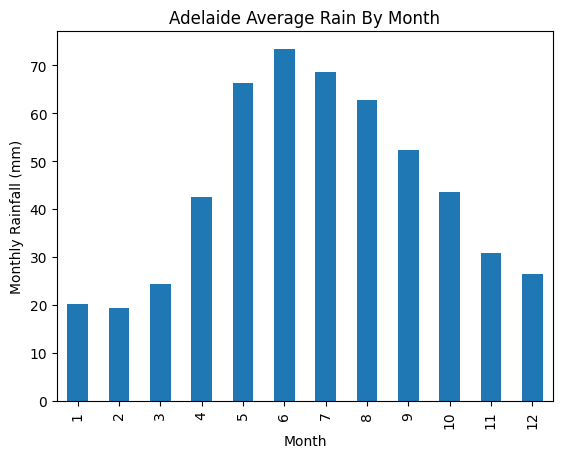

In [348]:
#graph for average rain
plt.title('Adelaide Average Rain By Month')
plt.xlabel('Month')
plt.ylabel('Monthly Rainfall (mm)')
monthly_average.plot(kind='bar')
plt.show()



In [ ]:
#Get only winter months to see if that shows change. (pre/post-1970)

winter = df_combined[df_combined['Month'].isin([5, 6, 7, 8])]

pre_1970_winter = winter[winter['Year'] < 1970].groupby('Year')['Rainfall amount (millimetres)'].sum().mean()
post_1970_winter = winter[winter['Year'] >= 1970].groupby('Year')['Rainfall amount (millimetres)'].sum().mean()

print("Pre 1970 winter rainfall:", pre_1970_winter)
print("Post 1970 winter rainfall:", post_1970_winter)



Pre 1970 winter rainfall: 270.3351145038168
Post 1970 winter rainfall: 271.88928571428573


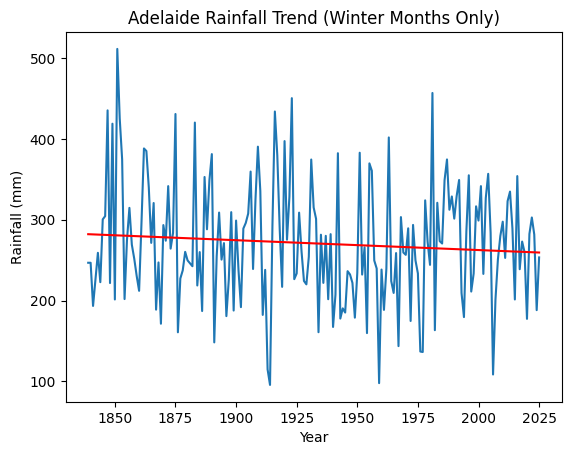

In [356]:
winter_yearly = winter.groupby('Year')['Rainfall amount (millimetres)'].sum()

# Plot
winter_yearly.plot(kind='line')

# Trend line
z = np.polyfit(winter_yearly.index, winter_yearly.values, 1)
p = np.poly1d(z)
plt.plot(winter_yearly.index, p(winter_yearly.index), color='red', label='Trend')

plt.title('Adelaide Rainfall Trend (Winter Months Only)')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.show()

This line chart shows a minor downward trend of yearly rainfall during winter months. While still not overly significant, the downward trend is more pronounced than in the all seasons yearly rainfall line graph. This potentially suggests that rainfall is overall staying more or less the same, but winter months are seeing slightly less rain. These findings seems somewhat consistent with climate trends research in southern Australia, which sees a decrease in rainfall during the cool season. 